# CelebA Attribute Analysis

Analyse every CelebA attribute: how many **smile** vs **non-smile** images fall under each attribute class.
Used to design OOD certification subsets (50 smile + 50 non-smile per attribute).

In [2]:
import sys, os, random
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── Academic style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'legend.fontsize':   10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   10,
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

PALETTE = {'smile': '#1b7837', 'no_smile': '#762a83'}

# ── Paths ──────────────────────────────────────────────────────────────────────
CELEBA_ROOT = Path("/BS/databases08/CelebA")
ATTR_FILE   = CELEBA_ROOT / "Anno" / "list_attr_celeba.txt"

TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
SPLIT_SEED  = 73

print("Attribute file exists:", ATTR_FILE.exists())

Attribute file exists: True


## 1. Load Full Attribute Table

In [3]:
def load_celeba_attrs(attr_path):
    lines = [l.strip() for l in attr_path.read_text().splitlines() if l.strip()]
    attr_names = lines[1].split()
    rows = []
    for line in lines[2:]:
        parts = line.split()
        rows.append([parts[0]] + [int(v) for v in parts[1:]])
    df = pd.DataFrame(rows, columns=["filename"] + attr_names)
    for col in attr_names:
        df[col] = (df[col] == 1).astype(int)
    return df

def assign_splits(df, train_ratio, val_ratio, seed):
    filenames = df["filename"].tolist()
    rng = random.Random(seed)
    shuffled = list(filenames)
    rng.shuffle(shuffled)
    n_train = int(len(shuffled) * train_ratio)
    n_val   = int(len(shuffled) * val_ratio)
    split_map = (
        {f: "train" for f in shuffled[:n_train]}
        | {f: "val"   for f in shuffled[n_train:n_train + n_val]}
        | {f: "test"  for f in shuffled[n_train + n_val:]}
    )
    df = df.copy()
    df["split"] = df["filename"].map(split_map)
    return df

df = load_celeba_attrs(ATTR_FILE)
df = assign_splits(df, TRAIN_RATIO, VAL_RATIO, SPLIT_SEED)
ATTR_COLS = [c for c in df.columns if c not in ("filename", "split")]
df_test   = df[df["split"] == "test"].copy()

print(f"Total: {len(df):,}  |  train: {(df.split=='train').sum():,}  "
      f"val: {(df.split=='val').sum():,}  test: {(df.split=='test').sum():,}")

Total: 202,599  |  train: 162,079  val: 20,259  test: 20,261


## 2. Per-Attribute Smile Counts (Test Split)

In [4]:
def attr_smile_table(df_sub, label=""):
    total = len(df_sub)
    records = []
    for attr in ATTR_COLS:
        sub = df_sub[df_sub[attr] == 1]
        n_attr   = len(sub)
        n_smile  = int(sub["Smiling"].sum())
        n_nsmile = n_attr - n_smile
        feasible = (n_smile >= 50) and (n_nsmile >= 50)
        records.append({
            "Attribute":            attr,
            "Attr=1 count":         n_attr,
            "% of split":           round(100 * n_attr / total, 1),
            "Smile":                n_smile,
            "Non-smile":            n_nsmile,
            "Smile %":              round(100 * n_smile / n_attr, 1) if n_attr else 0,
            "OOD feasible":         feasible,
        })
    return pd.DataFrame(records).sort_values("Attr=1 count", ascending=False).reset_index(drop=True)

tbl_test = attr_smile_table(df_test, "test")
feasible_attrs = tbl_test[tbl_test["OOD feasible"]].copy()
print(f"OOD-feasible attributes: {len(feasible_attrs)}")
display(tbl_test.style.format({
    "Attr=1 count": "{:,}", "Smile": "{:,}", "Non-smile": "{:,}",
    "% of split": "{:.1f}%", "Smile %": "{:.1f}%"
}))

OOD-feasible attributes: 39


,Attribute,Attr=1 count,% of split,Smile,Non-smile,Smile %,OOD feasible
0,No_Beard,"16,943",83.6%,"8,632","8,311",50.9%,True
1,Young,"15,558",76.8%,"7,391","8,167",47.5%,True
2,Attractive,"10,265",50.7%,"5,783","4,482",56.3%,True
3,Smiling,"9,793",48.3%,"9,793",0,100.0%,False
4,Mouth_Slightly_Open,"9,783",48.3%,"7,427","2,356",75.9%,True
5,Wearing_Lipstick,"9,515",47.0%,"5,588","3,927",58.7%,True
6,High_Cheekbones,"9,275",45.8%,"7,961","1,314",85.8%,True
7,Male,"8,452",41.7%,"3,370","5,082",39.9%,True
8,Heavy_Makeup,"7,808",38.5%,"4,697","3,111",60.2%,True
9,Wavy_Hair,"6,450",31.8%,"3,528","2,922",54.7%,True


## 3. Figure 1 — Smile vs Non-smile Count per Attribute (Test Split)

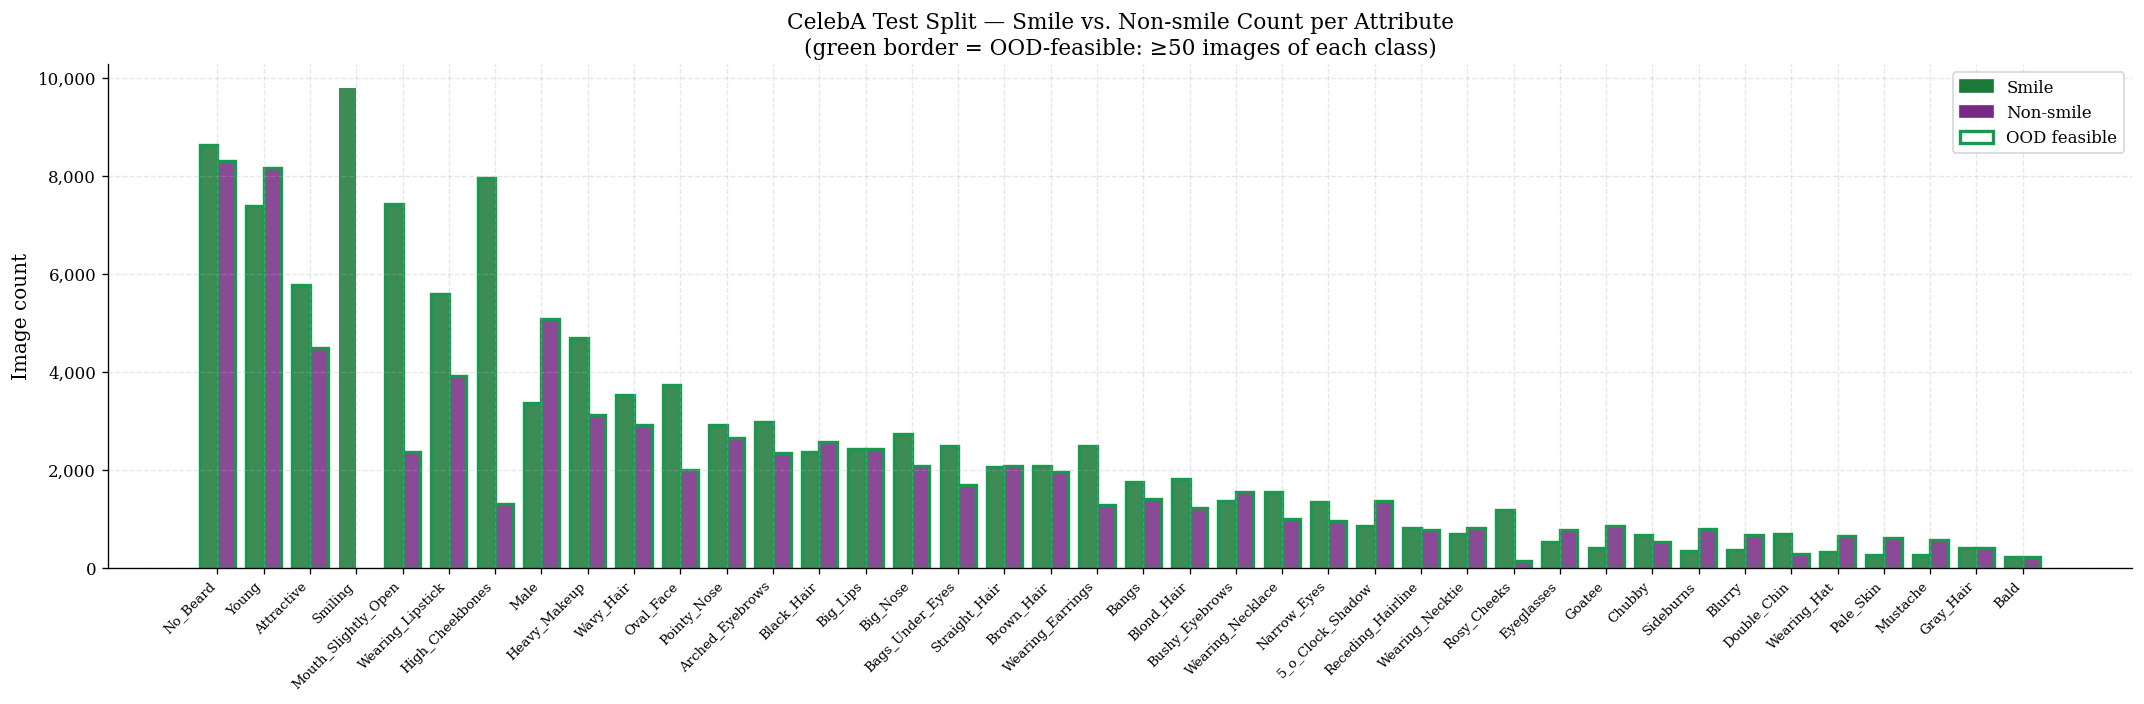

In [5]:
fig, ax = plt.subplots(figsize=(18, 6))

attrs  = tbl_test["Attribute"].tolist()
smiles = tbl_test["Smile"].tolist()
nsmile = tbl_test["Non-smile"].tolist()
feasible_flags = tbl_test["OOD feasible"].tolist()

x = np.arange(len(attrs))
w = 0.38
ax.bar(x - w/2, smiles, w, label="Smile",     color=PALETTE['smile'],    alpha=0.85)
ax.bar(x + w/2, nsmile, w, label="Non-smile", color=PALETTE['no_smile'], alpha=0.85)

# mark OOD-feasible with green border
for i, f in enumerate(feasible_flags):
    if f:
        ax.bar(x[i] - w/2, smiles[i], w, color='none', edgecolor='#1a9850', linewidth=2)
        ax.bar(x[i] + w/2, nsmile[i], w, color='none', edgecolor='#1a9850', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(attrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Image count")
ax.set_title("CelebA Test Split — Smile vs. Non-smile Count per Attribute\n"
             "(green border = OOD-feasible: \u226550 images of each class)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['smile'],    label='Smile'),
    mpatches.Patch(color=PALETTE['no_smile'], label='Non-smile'),
    mpatches.Patch(facecolor='none', edgecolor='#1a9850', linewidth=2, label='OOD feasible'),
])
plt.tight_layout()
plt.savefig("fig_attr_smile_counts.pdf", bbox_inches='tight')
plt.show()

## 4. Figure 2 — Smile Imbalance Ranking

/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


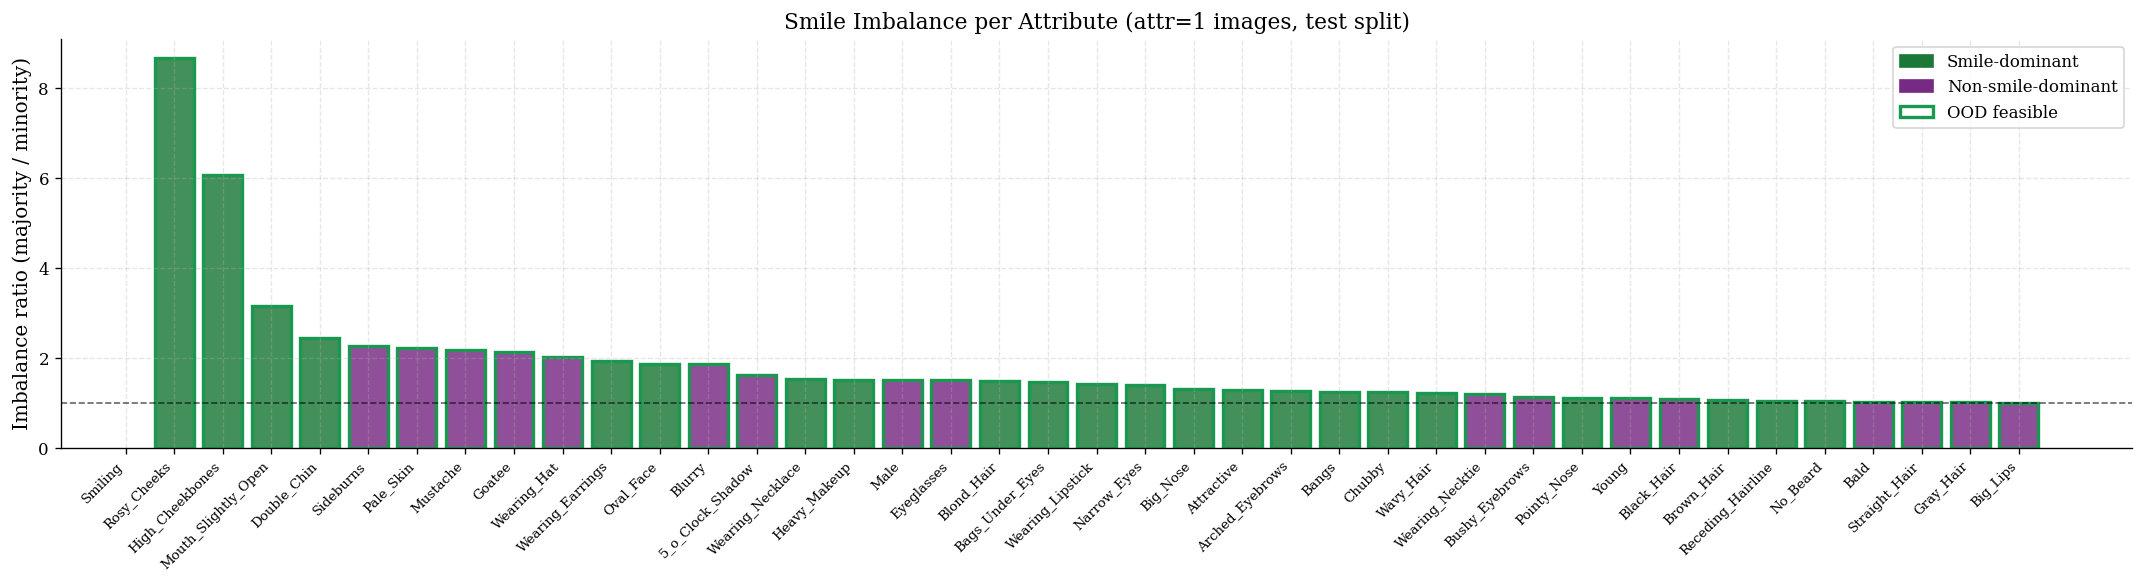

,Attribute,Smile,Non-smile,Smile %,Imbalance ratio,Dominant,OOD feasible
29,Rosy_Cheeks,"1,178",136,89.6%,8.66,smile,True
19,High_Cheekbones,"7,961","1,314",85.8%,6.06,smile,True
21,Mouth_Slightly_Open,"7,427","2,356",75.9%,3.15,smile,True
14,Double_Chin,697,284,71.0%,2.45,smile,True
30,Sideburns,354,801,30.6%,2.26,non-smile,True
26,Pale_Skin,272,601,31.2%,2.21,non-smile,True
22,Mustache,263,571,31.5%,2.17,non-smile,True
16,Goatee,402,860,31.9%,2.14,non-smile,True
35,Wearing_Hat,322,648,33.2%,2.01,non-smile,True
34,Wearing_Earrings,"2,494","1,287",66.0%,1.94,smile,True


In [6]:
imb_records = []
for attr in ATTR_COLS:
    sub = df_test[df_test[attr] == 1]
    n = len(sub)
    if n == 0: continue
    ns  = int(sub["Smiling"].sum())
    nns = n - ns
    minority = min(ns, nns)
    majority = max(ns, nns)
    ratio    = majority / minority if minority > 0 else np.inf
    imb_records.append({
        "Attribute":      attr,
        "Smile":          ns,
        "Non-smile":      nns,
        "Smile %":        round(100*ns/n, 1),
        "Imbalance ratio": round(ratio, 2),
        "Dominant":       "smile" if ns > nns else "non-smile",
        "OOD feasible":   (ns >= 50) and (nns >= 50),
    })
imb_df = pd.DataFrame(imb_records).sort_values("Imbalance ratio", ascending=False)

fig, ax = plt.subplots(figsize=(18, 5))
colors = [PALETTE['smile'] if d == 'smile' else PALETTE['no_smile']
          for d in imb_df['Dominant']]
ax.bar(imb_df['Attribute'], imb_df['Imbalance ratio'], color=colors, alpha=0.82, edgecolor='white')

for i, (f, r) in enumerate(zip(imb_df['OOD feasible'], imb_df['Imbalance ratio'])):
    if f:
        ax.bar(imb_df['Attribute'].iloc[i], r, color='none', edgecolor='#1a9850', linewidth=2)

ax.axhline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xticks(range(len(imb_df)))
ax.set_xticklabels(imb_df['Attribute'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Imbalance ratio (majority / minority)")
ax.set_title("Smile Imbalance per Attribute (attr=1 images, test split)")
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['smile'],    label='Smile-dominant'),
    mpatches.Patch(color=PALETTE['no_smile'], label='Non-smile-dominant'),
    mpatches.Patch(facecolor='none', edgecolor='#1a9850', linewidth=2, label='OOD feasible'),
])
plt.tight_layout()
plt.savefig("fig_attr_imbalance.pdf", bbox_inches='tight')
plt.show()

display(imb_df[imb_df['OOD feasible']].style.format({
    'Smile':'{:,}', 'Non-smile':'{:,}', 'Smile %':'{:.1f}%', 'Imbalance ratio':'{:.2f}'
}))

## 5. Figure 3 — Smile % for OOD-Feasible Attributes (Horizontal Bar)

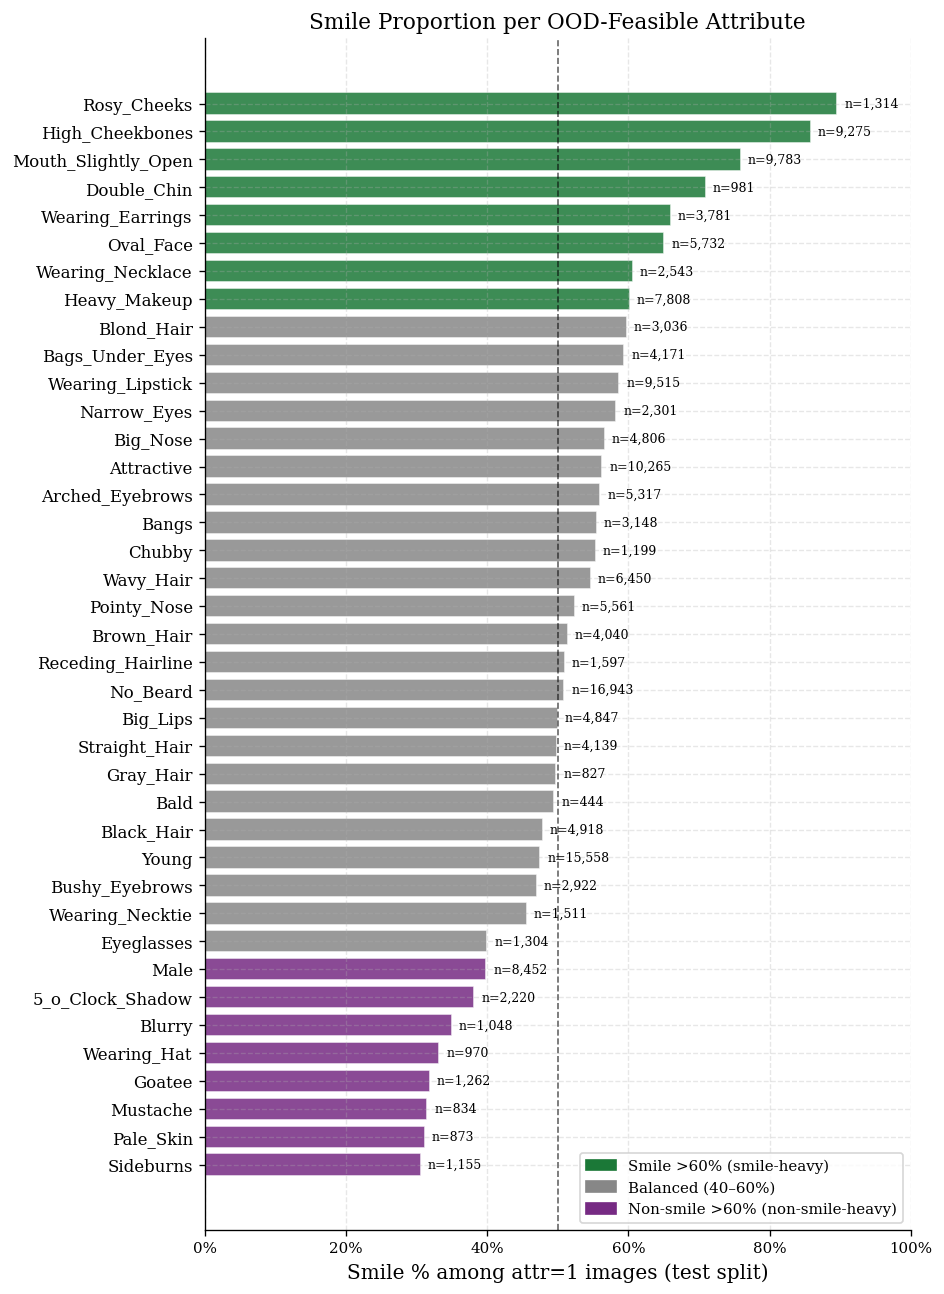

In [7]:
# Show smile % for each OOD-feasible attribute — sorted ascending
# Red zone < 40%, green zone > 60%, neutral otherwise
feas = feasible_attrs.sort_values("Smile %")
pcts = feas["Smile %"].values
labels = feas["Attribute"].values
colors_pct = ['#762a83' if p < 40 else '#1b7837' if p > 60 else '#878787' for p in pcts]

fig, ax = plt.subplots(figsize=(8, max(6, len(feas)*0.28)))
bars = ax.barh(labels, pcts, color=colors_pct, alpha=0.85, edgecolor='white')
ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.6, label='50% balanced')
ax.set_xlabel("Smile % among attr=1 images (test split)")
ax.set_title("Smile Proportion per OOD-Feasible Attribute")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(handles=[
    mpatches.Patch(color='#1b7837', label='Smile >60% (smile-heavy)'),
    mpatches.Patch(color='#878787', label='Balanced (40–60%)'),
    mpatches.Patch(color='#762a83', label='Non-smile >60% (non-smile-heavy)'),
], loc='lower right', fontsize=9)

# annotate count
for bar, (_, row) in zip(bars, feas.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"n={row['Attr=1 count']:,}", va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig("fig_attr_smile_pct.pdf", bbox_inches='tight')
plt.show()

## 6. Smile Rate Heatmap (Top OOD Attributes)

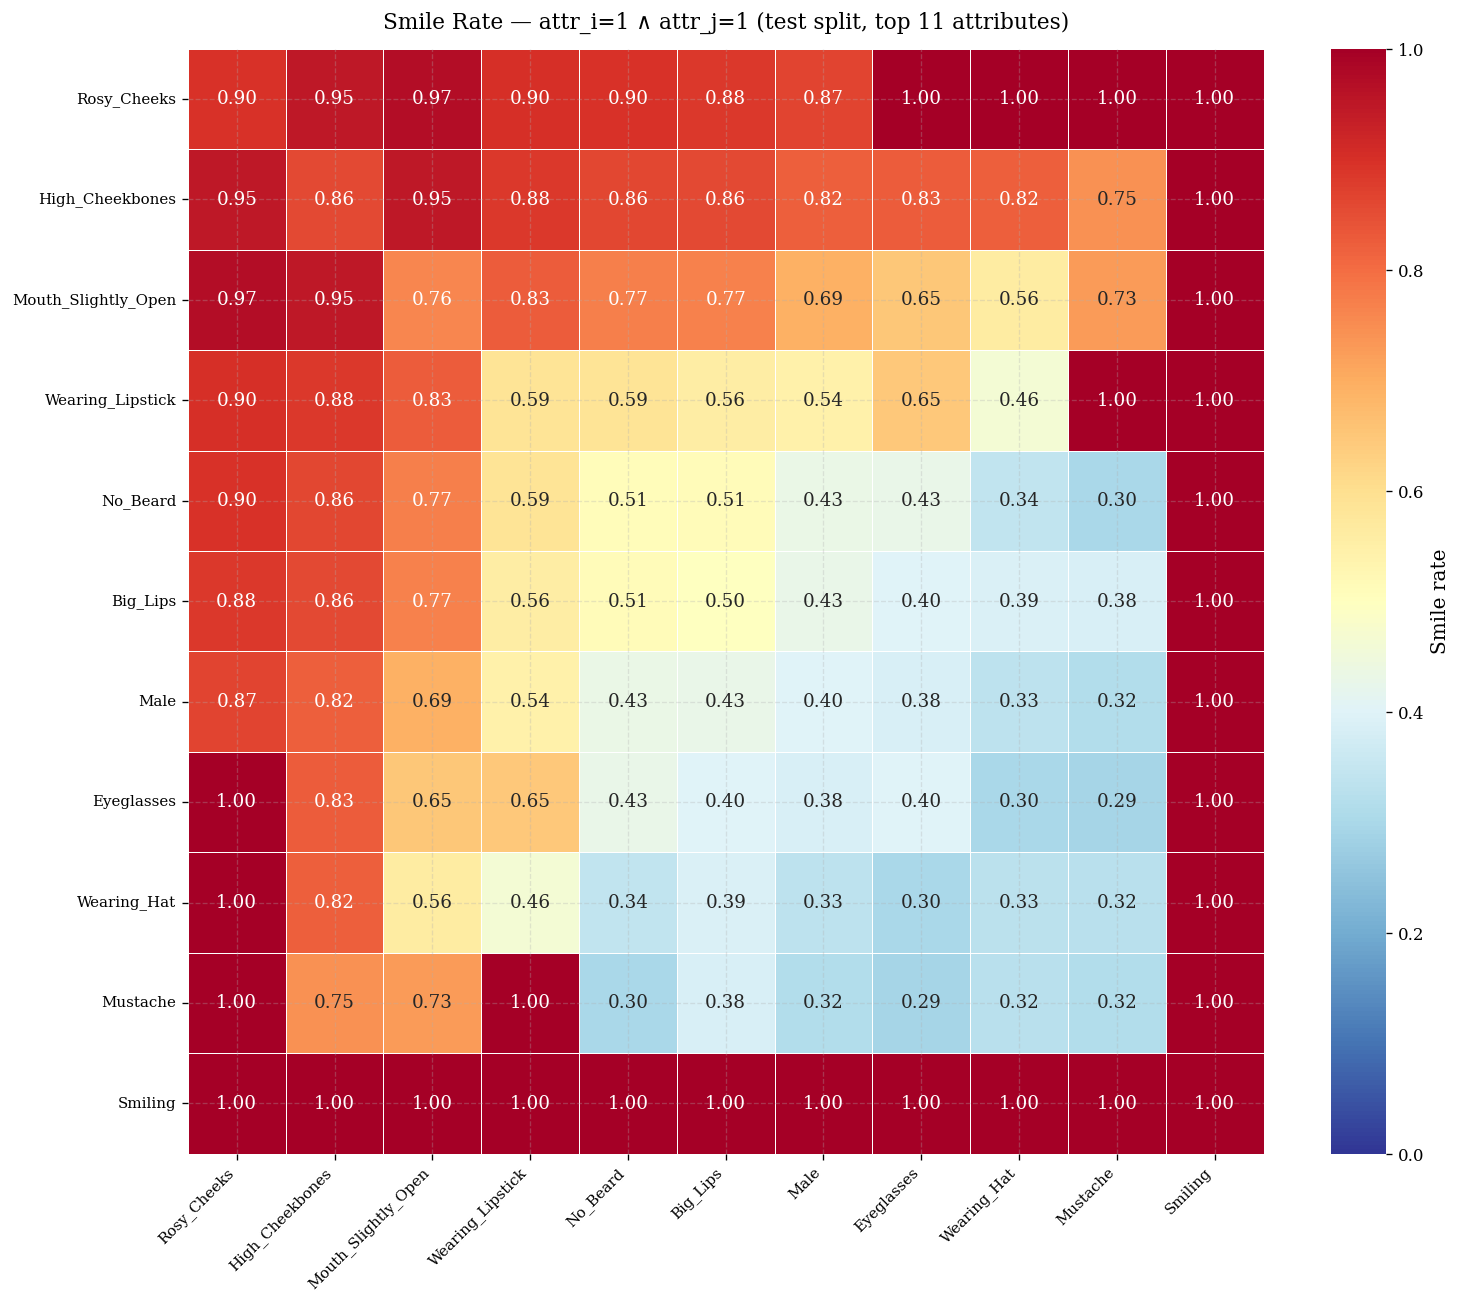

In [20]:

TOP_N = 11
# top_attrs = feasible_attrs.nlargest(TOP_N, "Attr=1 count")["Attribute"].tolist()
top_attrs = [
    "Rosy_Cheeks",
    "High_Cheekbones",
    "Mouth_Slightly_Open",
    "Wearing_Lipstick",
    "No_Beard",
    "Big_Lips",
    "Male",
    "Eyeglasses",
    "Wearing_Hat",
    "Mustache",
    "Smiling"
]

smile_rates = np.zeros((TOP_N, TOP_N))
for i, a in enumerate(top_attrs):
    for j, b in enumerate(top_attrs):
        sub = df_test[(df_test[a] == 1) & (df_test[b] == 1)]
        smile_rates[i, j] = sub["Smiling"].mean() if len(sub) > 0 else np.nan

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    smile_rates, annot=True, fmt=".2f", cmap="RdYlBu_r",
    xticklabels=top_attrs, yticklabels=top_attrs,
    vmin=0, vmax=1, linewidths=0.4, ax=ax, cbar_kws={"label": "Smile rate"}
)
ax.set_title(f"Smile Rate — attr_i=1 ∧ attr_j=1 (test split, top {TOP_N} attributes)",
             pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("fig_smile_heatmap.pdf", bbox_inches='tight')
plt.show()

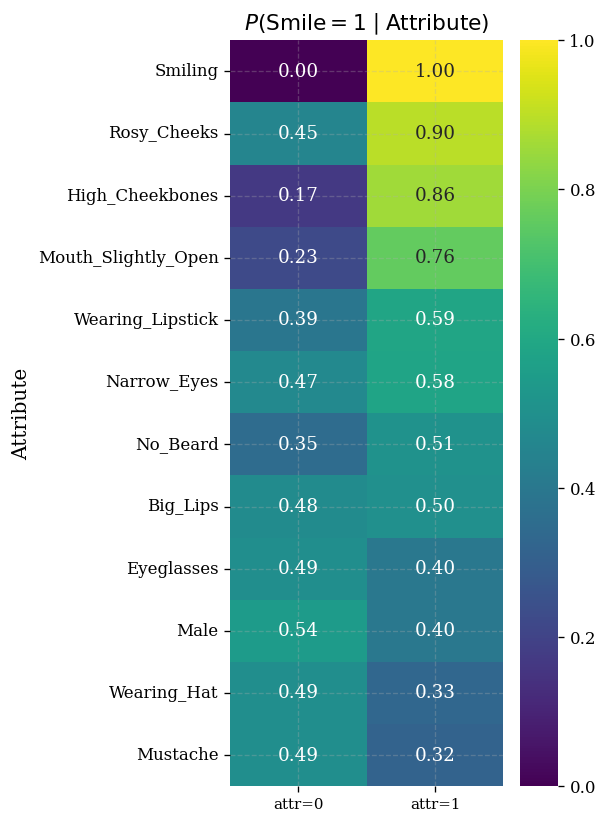

In [23]:
ood_attrs = [
    "No_Beard",
    "Mouth_Slightly_Open",
    "Wearing_Lipstick",
    "High_Cheekbones",
    "Male",
    "Big_Lips",
    "Narrow_Eyes",
    "Rosy_Cheeks",
    "Eyeglasses",
    "Wearing_Hat",
    "Mustache",
    "Smiling"
]

rows = []

for attr in ood_attrs:
    smile_if_1 = df_test[df_test[attr] == 1]["Smiling"].mean()
    smile_if_0 = df_test[df_test[attr] == 0]["Smiling"].mean()

    rows.append({
        "Attribute": attr,
        "attr=0": smile_if_0,
        "attr=1": smile_if_1,
    })

heat_df = (
    pd.DataFrame(rows)
    .sort_values("attr=1", ascending=False)
    .set_index("Attribute")
)

plt.figure(figsize=(5,7))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1
)
plt.title(r"$P(\mathrm{Smile}=1 \mid \mathrm{Attribute})$")
plt.tight_layout()
plt.show()

<Axes: >

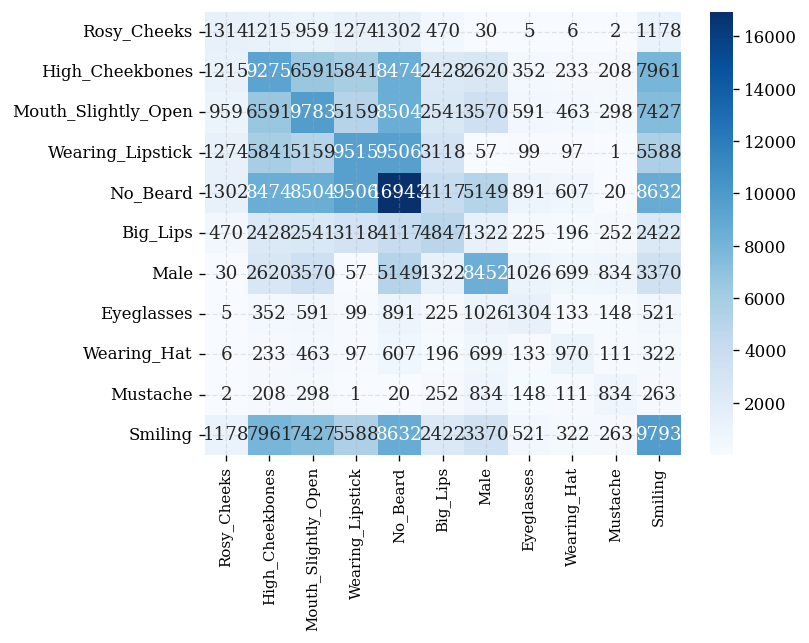

In [22]:
# To verify,

count_mat = np.zeros((len(top_attrs), len(top_attrs)))

for i, a in enumerate(top_attrs):
    for j, b in enumerate(top_attrs):
        count_mat[i,j] = ((df_test[a]==1) & (df_test[b]==1)).sum()


sns.heatmap(
    count_mat,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=top_attrs,
    yticklabels=top_attrs
)

## 7. Summary Table for Paper

In [8]:
# Compact table for all OOD-feasible attributes — ready to paste into paper
paper_tbl = feasible_attrs[[
    "Attribute", "Attr=1 count", "% of split", "Smile", "Non-smile", "Smile %"
]].copy()
paper_tbl.columns = ["Attribute", "N (attr=1)", "% of test", "Smile", "Non-smile", "Smile %"]
paper_tbl = paper_tbl.sort_values("N (attr=1)", ascending=False).reset_index(drop=True)

print(f"OOD-feasible attributes: {len(paper_tbl)}")
display(paper_tbl.style.format({
    "N (attr=1)": "{:,}",
    "Smile":      "{:,}",
    "Non-smile":  "{:,}",
    "% of test":  "{:.1f}%",
    "Smile %":    "{:.1f}%",
}).bar(subset=["Smile %"], color=['#762a83', '#1b7837'], vmin=0, vmax=100))

# Print which OOD classifiers we trained
print("\nOOD attributes used in experiments:")
OOD_TRAINED = [
    "Wearing_Hat", "Eyeglasses", "Male", "Wearing_Lipstick",
    "Mouth_Slightly_Open", "High_Cheekbones", "Big_Lips",
    "Narrow_Eyes", "Mustache", "No_Beard", "Rosy_Cheeks"
]
sub = paper_tbl[paper_tbl["Attribute"].isin(OOD_TRAINED)]
display(sub.style.format({"N (attr=1)":"{:,}","Smile":"{:,}","Non-smile":"{:,}","Smile %":"{:.1f}%"}))

OOD-feasible attributes: 39


,Attribute,N (attr=1),% of test,Smile,Non-smile,Smile %
0,No_Beard,"16,943",83.6%,"8,632","8,311",50.9%
1,Young,"15,558",76.8%,"7,391","8,167",47.5%
2,Attractive,"10,265",50.7%,"5,783","4,482",56.3%
3,Mouth_Slightly_Open,"9,783",48.3%,"7,427","2,356",75.9%
4,Wearing_Lipstick,"9,515",47.0%,"5,588","3,927",58.7%
5,High_Cheekbones,"9,275",45.8%,"7,961","1,314",85.8%
6,Male,"8,452",41.7%,"3,370","5,082",39.9%
7,Heavy_Makeup,"7,808",38.5%,"4,697","3,111",60.2%
8,Wavy_Hair,"6,450",31.8%,"3,528","2,922",54.7%
9,Oval_Face,"5,732",28.3%,"3,733","1,999",65.1%



OOD attributes used in experiments:


,Attribute,N (attr=1),% of test,Smile,Non-smile,Smile %
0,No_Beard,"16,943",83.600000,"8,632","8,311",50.9%
3,Mouth_Slightly_Open,"9,783",48.300000,"7,427","2,356",75.9%
4,Wearing_Lipstick,"9,515",47.000000,"5,588","3,927",58.7%
5,High_Cheekbones,"9,275",45.800000,"7,961","1,314",85.8%
6,Male,"8,452",41.700000,"3,370","5,082",39.9%
13,Big_Lips,"4,847",23.900000,"2,422","2,425",50.0%
23,Narrow_Eyes,"2,301",11.400000,"1,342",959,58.3%
27,Rosy_Cheeks,"1,314",6.500000,"1,178",136,89.6%
28,Eyeglasses,"1,304",6.400000,521,783,40.0%
34,Wearing_Hat,970,4.800000,322,648,33.2%
